In [156]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


# 연습문제 처리방향
1. 데이터 셋 생성 & 전처리
```
    * 엑셀 -> 데이터프레임 -> ?처리 (df.replace('?', np.nan) -> 결측치처리
     -> X, y 분리 -> X 변수 스케일 조정 -> train_test_spilt
     (분류분석) -> y 변수들의 원핫인코딩     
```
2. 모델 생성 (이진분석 : 입력 13, 출력 1   /   분류분석 : 입력 13, 출력 2)  # 분류분석은 원핫인코딩으로 출력수 증가
3. 모델 학습과정 설정 & 학습
4. 모델평가 (그래프, 평가, 교차표)
5. 모델 사용(저장, 예측)

In [2]:
import numpy as np
import pandas as pd
import sys
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix # 혼동행렬
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split  # 데이터 분리

# <이진분석>
## 1. 데이터셋 생성 및 전처리

In [ ]:
df = pd.read_excel('data/heart-disease.xlsx')
df

### 컬럼명	의미 및 설명

- cp	흉통의 유형 (Chest Pain type)
    - 0: 전형적 협심증 / 1: 비전형적 협심증 / 2: 비심장성 흉통 / 3: 무증상
- treshtbps	안정 시 수축기 혈압 (Resting Blood Pressure in mm Hg)
- chol	혈청 콜레스테롤 수치 (Serum Cholesterol in mg/dl)
- fbs	공복혈당 120mg/dl 이상 여부 (Fasting Blood Sugar) - 1: Yes, 0: No
- restecg	안정 시 심전도 결과 (Resting Electrocardiographic Results)
    - 0: 정상 / 1: ST-T 이상 / 2: 좌심실 비대 가능성
- thalach	최대 심박수 (Maximum Heart Rate Achieved)
- exang	운동 중 협심증 여부 (Exercise Induced Angina) - 1: 있음, 0: 없음
- oldpeak	운동 후 ST 감소 정도 (ST Depression induced by exercise relative to rest)
- slope	ST segment의 기울기 (Slope of the peak exercise ST segment)
    - 1: 수평  / 2: 상승  / 3: 하강
- ca	형광투시검사에서 관찰된 주요 혈관 수 (Number of major vessels colored by fluoroscopy)
- hsl (일반적으로 thal로 표기됨)	지혈소 상태 (Thalassemia)
    - 3: 정상 / 6: 고정결함 / 7: 가역적 결함
- heartDisease	심장병 여부 (Target Variable)
    - 1: 심장병 있음 / 0: 없음

In [5]:
df.isin(['?']).any()

age             False
sex             False
cp              False
treshtbps       False
chol             True
fbs             False
restecg         False
thalach         False
exang           False
oldpeak         False
slope           False
ca               True
hsl              True
heartDisease    False
dtype: bool

In [11]:
df.replace('?', np.nan, inplace=True)

In [15]:
df.isna().sum()

age             0
sex             0
cp              0
treshtbps       0
chol            1
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              4
hsl             2
heartDisease    0
dtype: int64

In [16]:
df

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
0,63,1,1,145,233.0,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286.0,0,0,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,NaN,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250.0,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204.0,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264.0,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193.0,1,0,141,0,3.4,2,2.0,7.0,1
300,57,1,4,130,131.0,0,0,115,1,1.2,2,1.0,7.0,1
301,57,0,2,130,236.0,0,2,174,0,0.0,2,1.0,3.0,1


In [18]:
df = df.dropna().reset_index(drop=True)

In [19]:
df

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
0,63,1,1,145,233.0,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286.0,0,0,108,1,1.5,2,3.0,3.0,1
2,37,1,3,130,250.0,0,0,187,0,3.5,3,0.0,3.0,0
3,41,0,2,130,204.0,0,2,172,0,1.4,1,0.0,3.0,0
4,56,1,2,120,236.0,0,0,178,0,0.8,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,57,0,4,140,241.0,0,0,123,1,0.2,2,0.0,7.0,1
292,45,1,1,110,264.0,0,0,132,0,1.2,2,0.0,7.0,1
293,68,1,4,144,193.0,1,0,141,0,3.4,2,2.0,7.0,1
294,57,1,4,130,131.0,0,0,115,1,1.2,2,1.0,7.0,1


In [132]:
# X, y 분리 
X_data = df.iloc[:,:-1].values
y_data = df.iloc[:,-1].values
X_data.shape, y_data.shape

#  X 변수 스케일 조정 
scaler_X =  MinMaxScaler()
scaled_X_data = scaler_X.fit_transform(X_data)

# train_test_spilt
X_train, X_test, y_train, y_test = train_test_split(scaled_X_data, y_data, 
                                                    test_size=0.3, # 테스트셋 비율
                                                    shuffle=True, 
                                                    random_state=7,
                                                    stratify=y_data) # 층화추출


print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(scaled_X_data[:5])
print(X_train[:5], y_train[:5])

(207, 13) (89, 13) (207,) (89,)
[[0.70833333 1.         0.         0.48113208 0.24429224 1.
  1.         0.60305344 0.         0.37096774 1.         0.
  0.75      ]
 [0.79166667 1.         1.         0.62264151 0.3652968  0.
  0.         0.28244275 1.         0.24193548 0.5        1.
  0.        ]
 [0.16666667 1.         0.66666667 0.33962264 0.28310502 0.
  0.         0.88549618 0.         0.56451613 1.         0.
  0.        ]
 [0.25       0.         0.33333333 0.33962264 0.17808219 0.
  1.         0.77099237 0.         0.22580645 0.         0.
  0.        ]
 [0.5625     1.         0.33333333 0.24528302 0.25114155 0.
  0.         0.81679389 0.         0.12903226 0.         0.
  0.        ]]
[[0.29166667 1.         0.66666667 0.33962264 0.43150685 0.
  0.         0.69465649 0.         0.30645161 0.         0.33333333
  0.        ]
 [0.79166667 1.         1.         0.24528302 0.25342466 0.
  0.         0.         0.         0.16129032 0.5        0.
  0.        ]
 [0.33333333 1.      

In [136]:
# 음성 양성 비율
print(pd.DataFrame(y_data).value_counts(normalize=True)) # 전체 데이터
print(pd.DataFrame(y_train).value_counts(normalize=True)) # 학습데이터
print(pd.DataFrame(y_test).value_counts(normalize=True)) # 시험데이터

0    0.540541
1    0.459459
dtype: float64
0    0.541063
1    0.458937
dtype: float64
0    0.539326
1    0.460674
dtype: float64


## 2. 모델 생성

In [149]:
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(units=39, activation='relu'))
model.add(Dropout(0.2))
#model.add(Dense(units=78, activation='relu'))
#model.add(Dropout(0.3))
model.add(Dense(units=26, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()

Model: "sequential_23"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_74 (Dense)            (None, 39)                546       
                                                                 
 dropout_21 (Dropout)        (None, 39)                0         
                                                                 
 dense_75 (Dense)            (None, 26)                1040      
                                                                 
 dense_76 (Dense)            (None, 1)                 27        
                                                                 
Total params: 1,613
Trainable params: 1,613
Non-trainable params: 0
_________________________________________________________________


## 3. 모델 학습 과정 설정 및 학습

In [150]:
model.compile(loss = 'binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy',   # 정확도
                      metrics.Recall(),  # 재현율(실제값 중심)
                      metrics.Precision()  # 정밀도(예측값 중심)
                      ])

In [151]:
%%time
hist = model.fit(X_train, y_train, # 훈련데이터
                epochs=200, # 학습횟수
                batch_size=200, # 한번에 읽어들이는 데이터 양
                validation_split= 0.2,  
                verbose=0              
                )

CPU times: total: 7.75 s
Wall time: 6.26 s


## 4. 모델평가하기

In [153]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall_3', 'precision_3', 'val_loss', 'val_accuracy', 'val_recall_3', 'val_precision_3'])

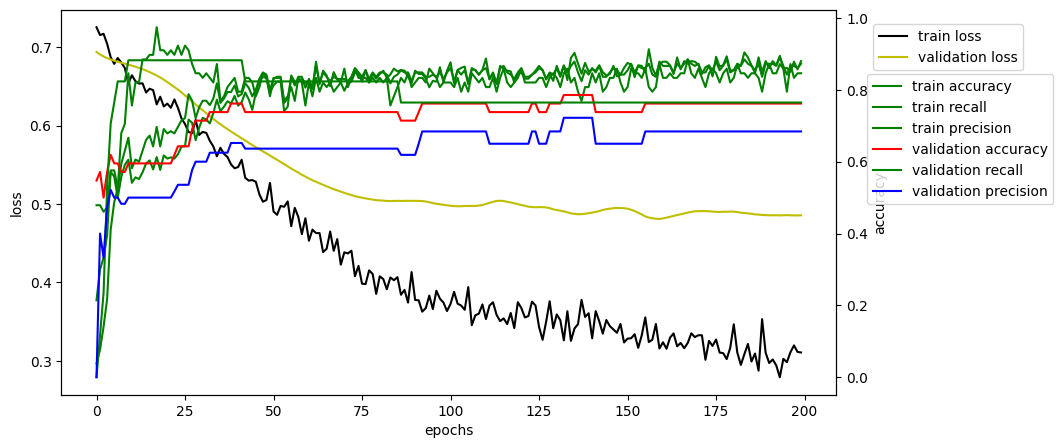

In [154]:
# 학습과정 그리기
fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist.history['loss'], 'k', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'y', label='validation loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history.get('accuracy'), 'g', label='train accuracy')
acc_ax.plot(hist.history.get('recall_3'), 'g', label='train recall')
acc_ax.plot(hist.history.get('precision_3'), 'g', label='train precision')
acc_ax.plot(hist.history.get('val_accuracy'), 'r', label='validation accuracy')
acc_ax.plot(hist.history.get('val_recall_3'), 'g', label='validation recall')
acc_ax.plot(hist.history.get('val_precision_3'), 'b', label='validation precision')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc = 'upper right', bbox_to_anchor=(1.25,0.98))
acc_ax.legend(loc = 'upper right', bbox_to_anchor=(1.289,0.85))

# 4. 모델 사용(저장, 예측)

In [155]:
model.save('model/07_heart.h5')

In [ ]:
model2

#  <분류분석>
## 1. 데이터셋 생성 및 전처리

In [61]:
df = pd.read_excel('data/heart-disease.xlsx')
df.replace('?', np.nan, inplace=True)
df = df.dropna().reset_index(drop=True)
df

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
0,63,1,1,145,233.0,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286.0,0,0,108,1,1.5,2,3.0,3.0,1
2,37,1,3,130,250.0,0,0,187,0,3.5,3,0.0,3.0,0
3,41,0,2,130,204.0,0,2,172,0,1.4,1,0.0,3.0,0
4,56,1,2,120,236.0,0,0,178,0,0.8,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,57,0,4,140,241.0,0,0,123,1,0.2,2,0.0,7.0,1
292,45,1,1,110,264.0,0,0,132,0,1.2,2,0.0,7.0,1
293,68,1,4,144,193.0,1,0,141,0,3.4,2,2.0,7.0,1
294,57,1,4,130,131.0,0,0,115,1,1.2,2,1.0,7.0,1


In [111]:
# X, y 분리 
X_data = df.iloc[:,:-1].values
y_data = df.iloc[:,-1].values
X_data.shape, y_data.shape

#  X 변수 스케일 조정 
scaler_X =  MinMaxScaler()
scaled_X_data = scaler_X.fit_transform(X_data)

# train_test_spilt
X_train, X_test, y_train, y_test = train_test_split(scaled_X_data, y_data, 
                                                    test_size=0.3, # 테스트셋 비율
                                                    shuffle=True, 
                                                    random_state=7,
                                                    stratify=y_data) # 층화추출

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(scaled_X_data[:2])
print(X_train[:2], y_train[:2])

# y 원핫인코딩

y_train_one_hot = to_categorical(y_data)
y_train_one_hot[1]

(207, 13) (89, 13) (207,) (89,)
[[0.70833333 1.         0.         0.48113208 0.24429224 1.
  1.         0.60305344 0.         0.37096774 1.         0.
  0.75      ]
 [0.79166667 1.         1.         0.62264151 0.3652968  0.
  0.         0.28244275 1.         0.24193548 0.5        1.
  0.        ]]
[[0.29166667 1.         0.66666667 0.33962264 0.43150685 0.
  0.         0.69465649 0.         0.30645161 0.         0.33333333
  0.        ]
 [0.79166667 1.         1.         0.24528302 0.25342466 0.
  0.         0.         0.         0.16129032 0.5        0.
  0.        ]] [0 1]


array([0., 1.], dtype=float32)

## 2. 모델생성

In [128]:
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(units=50, activation='relu'))
#model.add(Dropout(0.3))
model.add(Dense(units=100, activation='relu'))
#model.add(Dropout(0.3))
model.add(Dense(units=50, activation='relu'))
model.add(Dense(units=2, activation='softmax'))
model.summary()

Model: "sequential_20"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_62 (Dense)            (None, 50)                700       
                                                                 
 dense_63 (Dense)            (None, 100)               5100      
                                                                 
 dense_64 (Dense)            (None, 50)                5050      
                                                                 
 dense_65 (Dense)            (None, 2)                 102       
                                                                 
Total params: 10,952
Trainable params: 10,952
Non-trainable params: 0
_________________________________________________________________


## 3. 모델 학습 과정 설정 및 학습

In [135]:
# recall / precision을 추가로 받는게 편하다. 바로는 안되고 import 해야한다
from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam
model.compile(loss = 'categorical_crossentropy',
              optimizer=Adam(learning_rate=0.01),
              metrics=['accuracy',   # 정확도
                      metrics.Recall(),  # 재현율(실제값 중심)
                      metrics.Precision()  # 정밀도(예측값 중심)
                      ])

In [130]:
hist = model.fit(X_train, y_train_one_hot, # 훈련데이터
                epochs=200, # 학습횟수
                batch_size=100, # 한번에 읽어들이는 데이터 양
                validation_split= 0.3,  
                verbose=1              
                )

Epoch 1/200
2/2 [==============================] - 1s 225ms/step - loss: 0.7134 - accuracy: 0.5417 - recall: 0.5417 - precision: 0.5417 - val_loss: 0.6917 - val_accuracy: 0.5238 - val_recall: 0.5238 - val_precision: 0.5238
Epoch 2/200
2/2 [==============================] - 0s 32ms/step - loss: 0.6868 - accuracy: 0.5278 - recall: 0.5278 - precision: 0.5278 - val_loss: 0.6976 - val_accuracy: 0.5556 - val_recall: 0.5556 - val_precision: 0.5556
Epoch 3/200
2/2 [==============================] - 0s 30ms/step - loss: 0.6727 - accuracy: 0.5694 - recall: 0.5694 - precision: 0.5694 - val_loss: 0.7123 - val_accuracy: 0.5238 - val_recall: 0.5238 - val_precision: 0.5238
Epoch 4/200
2/2 [==============================] - 0s 34ms/step - loss: 0.6597 - accuracy: 0.5833 - recall: 0.5833 - precision: 0.5833 - val_loss: 0.7311 - val_accuracy: 0.5556 - val_recall: 0.5556 - val_precision: 0.5556
Epoch 5/200
2/2 [==============================] - 0s 31ms/step - loss: 0.6495 - accuracy: 0.6111 - recall: 0.6

Epoch 38/200
2/2 [==============================] - 0s 33ms/step - loss: 0.1270 - accuracy: 0.9444 - recall: 0.9444 - precision: 0.9444 - val_loss: 1.9674 - val_accuracy: 0.4603 - val_recall: 0.4603 - val_precision: 0.4603
Epoch 39/200
2/2 [==============================] - 0s 30ms/step - loss: 0.1647 - accuracy: 0.9097 - recall: 0.9097 - precision: 0.9097 - val_loss: 2.1164 - val_accuracy: 0.3968 - val_recall: 0.3968 - val_precision: 0.3968
Epoch 40/200
2/2 [==============================] - 0s 29ms/step - loss: 0.1139 - accuracy: 0.9514 - recall: 0.9514 - precision: 0.9514 - val_loss: 2.3372 - val_accuracy: 0.4127 - val_recall: 0.4127 - val_precision: 0.4127
Epoch 41/200
2/2 [==============================] - 0s 31ms/step - loss: 0.1195 - accuracy: 0.9583 - recall: 0.9583 - precision: 0.9583 - val_loss: 2.3718 - val_accuracy: 0.3968 - val_recall: 0.3968 - val_precision: 0.3968
Epoch 42/200
2/2 [==============================] - 0s 29ms/step - loss: 0.1003 - accuracy: 0.9583 - recall:

Epoch 75/200
2/2 [==============================] - 0s 30ms/step - loss: 0.0045 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - val_loss: 4.4770 - val_accuracy: 0.4127 - val_recall: 0.4127 - val_precision: 0.4127
Epoch 76/200
2/2 [==============================] - 0s 31ms/step - loss: 0.0043 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - val_loss: 4.5432 - val_accuracy: 0.4127 - val_recall: 0.4127 - val_precision: 0.4127
Epoch 77/200
2/2 [==============================] - 0s 30ms/step - loss: 0.0035 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - val_loss: 4.5944 - val_accuracy: 0.4127 - val_recall: 0.4127 - val_precision: 0.4127
Epoch 78/200
2/2 [==============================] - 0s 29ms/step - loss: 0.0032 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - val_loss: 4.6410 - val_accuracy: 0.4286 - val_recall: 0.4286 - val_precision: 0.4286
Epoch 79/200
2/2 [==============================] - 0s 32ms/step - loss: 0.0025 - accuracy: 1.0000 - recall:

Epoch 147/200
2/2 [==============================] - 0s 30ms/step - loss: 2.5287e-04 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - val_loss: 5.9337 - val_accuracy: 0.4127 - val_recall: 0.4127 - val_precision: 0.4127
Epoch 148/200
2/2 [==============================] - 0s 31ms/step - loss: 2.4697e-04 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - val_loss: 5.9471 - val_accuracy: 0.4127 - val_recall: 0.4127 - val_precision: 0.4127
Epoch 149/200
2/2 [==============================] - 0s 32ms/step - loss: 2.4220e-04 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - val_loss: 5.9638 - val_accuracy: 0.4127 - val_recall: 0.4127 - val_precision: 0.4127
Epoch 150/200
2/2 [==============================] - 0s 33ms/step - loss: 2.3852e-04 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - val_loss: 5.9803 - val_accuracy: 0.4127 - val_recall: 0.4127 - val_precision: 0.4127
Epoch 151/200
2/2 [==============================] - 0s 35ms/step - loss: 2.3500e-04 - a

Epoch 183/200
2/2 [==============================] - 0s 34ms/step - loss: 1.4262e-04 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - val_loss: 6.3010 - val_accuracy: 0.4127 - val_recall: 0.4127 - val_precision: 0.4127
Epoch 184/200
2/2 [==============================] - 0s 30ms/step - loss: 1.4044e-04 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - val_loss: 6.3085 - val_accuracy: 0.4127 - val_recall: 0.4127 - val_precision: 0.4127
Epoch 185/200
2/2 [==============================] - 0s 30ms/step - loss: 1.3808e-04 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - val_loss: 6.3194 - val_accuracy: 0.4127 - val_recall: 0.4127 - val_precision: 0.4127
Epoch 186/200
2/2 [==============================] - 0s 31ms/step - loss: 1.3516e-04 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - val_loss: 6.3302 - val_accuracy: 0.4127 - val_recall: 0.4127 - val_precision: 0.4127
Epoch 187/200
2/2 [==============================] - 0s 31ms/step - loss: 1.3471e-04 - a

In [119]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

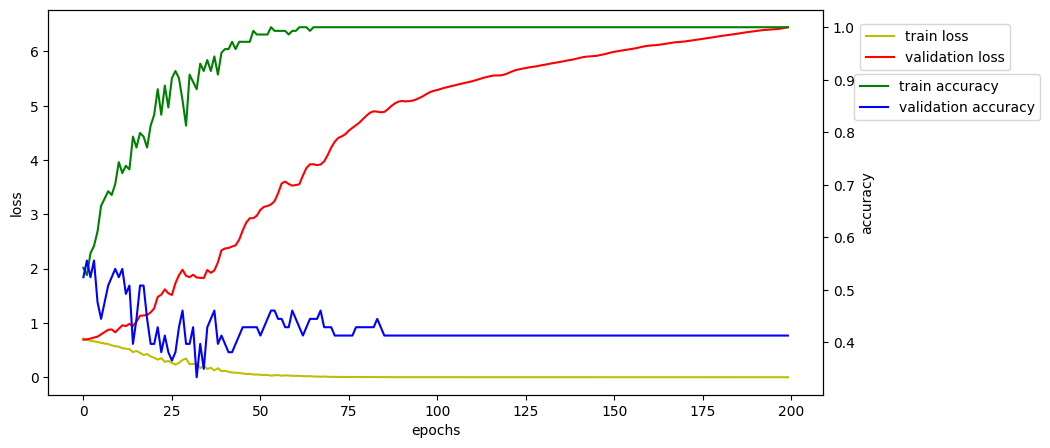

In [131]:
# 학습과정 그리기
fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='validation loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history.get('accuracy'), 'g', label='train accuracy')
acc_ax.plot(hist.history.get('val_accuracy'), 'b', label='validation accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc = 'upper right', bbox_to_anchor=(1.25,0.98))
acc_ax.legend(loc = 'upper right', bbox_to_anchor=(1.289,0.85))